Loading Dataset

/home/lab/jlacy/ECE9874-Project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'question_id': 'ammeter_1', 'question': 'What is the reading of the instrument?', 'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=800x564 at 0x7FCA954672F0>, 'image_type': 'ammeter', 'design': 'dial', 'evaluator': 'interval_matching', 'evaluator_kwargs': '{"interval": [6, 9], "units": ["mA", "milliampere"]}', 'meta_info': {'source': 'https://openclipart.org/detail/201462/ma-meter', 'uploader': 'k4r573n'}, 'split': 'real_world'}
1272
[6, 9]


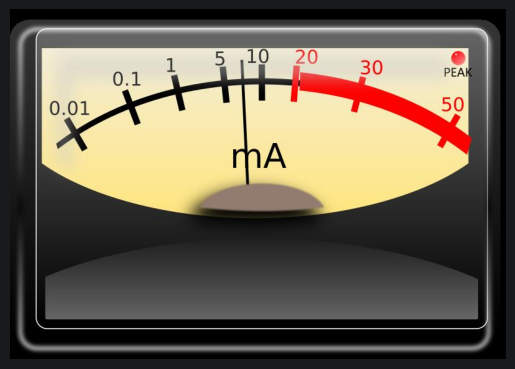

In [1]:
from datasets import load_dataset
from matplotlib import pyplot as plt
import json

dataset = load_dataset("FlagEval/MeasureBench", split="real_world")
print(dataset[1])
print(len(dataset))
print(json.loads(dataset[1]["evaluator_kwargs"])["interval"])

plt.imshow(dataset[1]["image"])
plt.axis("off")
plt.show()

Loading select VLMs for inference on the measurebench dataset

Comparing Size (Qwen 8B and 30B) (2 models)

Open Source vs Proprietary (Gemma3 vs Qwen) (1 more)

Maybe Quantization (1 more for both Qwen sizes)

5 Models total

In [2]:
import torch
import gc
from transformers import AutoProcessor, AutoModelForImageTextToText
from dotenv import load_dotenv

load_dotenv()

model = AutoModelForImageTextToText.from_pretrained("Qwen/Qwen3-VL-8B-Instruct", device_map="auto", torch_dtype="auto")
processor = AutoProcessor.from_pretrained("Qwen/Qwen3-VL-8B-Instruct")

for entry in dataset:
    image = entry["image"]
    question = entry["question"]

    messages = [
        {
          "role": "system",
          "content": [{"type": "text", "text": "You are a helpful chatbot, used for determining measurements on different instruments. Output only the answer, no other text"}],
        },
        {
          "role": "user",
          "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": question},
            ],
        },
    ]

    processed_chat = processor.apply_chat_template(messages, add_generation_prompt=True, tokenize=True, return_dict=True, return_tensors="pt")
    out = model.generate(**processed_chat.to(model.device), max_new_tokens=500)
    print(processor.decode(out[0]))
    try:
        print(json.loads(entry["evaluator_kwargs"])["interval"][0])
        break
    except KeyError:
        try:
            print(json.loads(entry["evaluator_kwargs"])["intervals"])

        except KeyError:
            print("No Interval or Intervals found")

del model
del processor
gc.collect()
torch.cuda.empty_cache()

Loading weights: 100%|██████████| 750/750 [03:01<00:00,  4.14it/s]


<|im_start|>system
You are a helpful chatbot, used for determining measurements on different instruments. Output only the answer, no other text<|im_end|>
<|im_start|>user
<|vision_start|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image